# 04 — Test-Set Evaluation
**Brugada-HUCA ECG Dataset**

This notebook produces the **final, held-out test-set results** for the tech report.

Contents:
1. Reload all trained models
2. Threshold optimisation (maximise F1 with sensitivity ≥ 0.85)
3. Full metrics table — LogReg / RF / ResNet1D
4. ROC and PR curve overlays
5. Confusion matrices
6. Error analysis: false positives and false negatives

## 0 — Setup

In [19]:
import sys, pickle
from pathlib import Path

_cwd = Path().resolve()
ROOT = next(
    (p for p in [_cwd, *_cwd.parents] if (p / 'src' / 'config.py').exists()),
    _cwd,
)
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

import config as cfg
from preprocessing import load_processed
from dataset import ECGDataset, make_loaders
from models import ResNet1D, CNN1D, RNN1D, BiLSTM1D, LSTM1D
from train import load_checkpoint
from evaluate import (
    predict_dl, compute_metrics, find_best_threshold,
    plot_confusion_matrix, plot_roc_pr_curves, compare_models,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


## 1 — Load Test Data and Models

In [2]:
X_train, y_train, ids_train = load_processed('train', cfg.DATA_PROCESSED)
X_val,   y_val,   ids_val   = load_processed('val',   cfg.DATA_PROCESSED)
X_test,  y_test,  ids_test  = load_processed('test',  cfg.DATA_PROCESSED)

print(f'Test set: {len(y_test)} samples  Brugada={(y_test==1).sum()}  Normal={(y_test==0).sum()}')

Test set: 55 samples  Brugada=12  Normal=43


In [3]:
# Load classical ML models + scaler
with open(cfg.MODELS_DIR / 'lr_best.pkl', 'rb') as f:
    lr = pickle.load(f)

with open(cfg.MODELS_DIR / 'rf_best.pkl', 'rb') as f:
    rf = pickle.load(f)

with open(cfg.MODELS_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load DL models
model = ResNet1D(n_leads=cfg.N_LEADS, base_channels=64).to(DEVICE)
best_epoch = load_checkpoint(cfg.MODELS_DIR / 'best_resnet1d.pt', model)
model.eval()

model_2 = CNN1D(n_leads=cfg.N_LEADS).to(DEVICE)
best_epoch_2 = load_checkpoint(cfg.MODELS_DIR / 'best_cnn1d.pt', model_2)
model_2.eval()

model_3 = RNN1D(n_leads=cfg.N_LEADS).to(DEVICE)
best_epoch_3 = load_checkpoint(cfg.MODELS_DIR / 'best_rnn1d.pt', model_3)
model_3.eval()

model_4 = BiLSTM1D(n_leads=cfg.N_LEADS).to(DEVICE)
best_epoch_4 = load_checkpoint(cfg.MODELS_DIR / 'best_bilstm1d.pt', model_4)
model_4.eval()

model_5 = LSTM1D(n_leads=cfg.N_LEADS).to(DEVICE)
best_epoch_5 = load_checkpoint(cfg.MODELS_DIR / 'best_lstm1d.pt', model_5)
model_5.eval()

print(f'ResNet1D loaded from epoch {best_epoch}')
print(f'CNN1D loaded from epoch {best_epoch_2}')
print(f'RNN1D loaded from epoch {best_epoch_3}')
print(f'BiLSTM1D loaded from epoch {best_epoch_4}')
print(f'LSTM1D loaded from epoch {best_epoch_5}')

ResNet1D loaded from epoch 12
CNN1D loaded from epoch 11
RNN1D loaded from epoch 13
BiLSTM1D loaded from epoch 13
LSTM1D loaded from epoch 21


In [4]:
# Feature matrix for ML models
df_test_feat  = pd.read_parquet(cfg.DATA_PROCESSED / 'features_test.parquet')
df_train_feat = pd.read_parquet(cfg.DATA_PROCESSED / 'features_train.parquet')
df_val_feat   = pd.read_parquet(cfg.DATA_PROCESSED / 'features_val.parquet')

X_te_ml = scaler.transform(df_test_feat.values)
X_vl_ml = scaler.transform(df_val_feat.values)

# DataLoader for DL model
splits = {
    'X_train': X_train, 'y_train': y_train, 'ids_train': ids_train,
    'X_val':   X_val,   'y_val':   y_val,   'ids_val':   ids_val,
    'X_test':  X_test,  'y_test':  y_test,  'ids_test':  ids_test,
}
loaders = make_loaders(splits, batch_size=cfg.BATCH_SIZE)
print('All models and data loaded.')

All models and data loaded.


## 2 — Get Predictions on Validation Set (for threshold tuning)

In [5]:
# Val probabilities (used only for threshold selection)
lr_prob_val  = lr.predict_proba(X_vl_ml)[:, 1]
rf_prob_val  = rf.predict_proba(X_vl_ml)[:, 1]
_, dl_prob_val = predict_dl(model, loaders['val'], device=DEVICE)
_, dl_prob_val_2 = predict_dl(model_2, loaders['val'], device=DEVICE)
_, dl_prob_val_3 = predict_dl(model_3, loaders['val'], device=DEVICE)
_, dl_prob_val_4 = predict_dl(model_4, loaders['val'], device=DEVICE)
_, dl_prob_val_5 = predict_dl(model_5, loaders['val'], device=DEVICE)

# Test probabilities
lr_prob_test  = lr.predict_proba(X_te_ml)[:, 1]
rf_prob_test  = rf.predict_proba(X_te_ml)[:, 1]
_, dl_prob_test = predict_dl(model, loaders['test'], device=DEVICE)
_, dl_prob_test_2 = predict_dl(model_2, loaders['test'], device=DEVICE)
_, dl_prob_test_3 = predict_dl(model_3, loaders['test'], device=DEVICE)
_, dl_prob_test_4 = predict_dl(model_4, loaders['test'], device=DEVICE)
_, dl_prob_test_5 = predict_dl(model_5, loaders['test'], device=DEVICE)

print('Predictions generated.')

Predictions generated.


## 3 — Threshold Optimisation

In a clinical setting, **sensitivity (recall) is paramount** — failing to detect a Brugada patient is dangerous.  
We find the threshold that maximises F1 score subject to sensitivity ≥ 0.85, using the **validation set**.

In [6]:
MIN_SENSITIVITY = 0.85

thresh_lr = find_best_threshold(y_val, lr_prob_val, metric='f1', min_sensitivity=MIN_SENSITIVITY)
thresh_rf = find_best_threshold(y_val, rf_prob_val, metric='f1', min_sensitivity=MIN_SENSITIVITY)
thresh_dl = find_best_threshold(y_val, dl_prob_val, metric='f1', min_sensitivity=MIN_SENSITIVITY)
thresh_dl_2 = find_best_threshold(y_val, dl_prob_val_2, metric='f1', min_sensitivity=MIN_SENSITIVITY)
thresh_dl_3 = find_best_threshold(y_val, dl_prob_val_3, metric='f1', min_sensitivity=MIN_SENSITIVITY)
thresh_dl_4 = find_best_threshold(y_val, dl_prob_val_4, metric='f1', min_sensitivity=MIN_SENSITIVITY)
thresh_dl_5 = find_best_threshold(y_val, dl_prob_val_5, metric='f1', min_sensitivity=MIN_SENSITIVITY)

print(f'Optimised thresholds (min sensitivity={MIN_SENSITIVITY}):')
print(f'  LogReg      : {thresh_lr:.3f}')
print(f'  RandomForest: {thresh_rf:.3f}')
print(f'  ResNet1D    : {thresh_dl:.3f}')
print(f'  CNN1D       : {thresh_dl_2:.3f}')
print(f'  RNN1D       : {thresh_dl_3:.3f}')
print(f'  BiLSTM1D    : {thresh_dl_4:.3f}')
print(f'  LSTM1D      : {thresh_dl_5:.3f}')

Optimised thresholds (min sensitivity=0.85):
  LogReg      : 0.020
  RandomForest: 0.158
  ResNet1D    : 0.772
  CNN1D       : 0.609
  RNN1D       : 0.312
  BiLSTM1D    : 0.198
  LSTM1D      : 0.248


## 4 — Test-Set Metrics

In [7]:
test_results = {
    'LogReg':       compute_metrics(y_test, lr_prob_test, threshold=thresh_lr),
    'RandomForest': compute_metrics(y_test, rf_prob_test, threshold=thresh_rf),
    'ResNet1D':     compute_metrics(y_test, dl_prob_test, threshold=thresh_dl),
    'CNN1D':  compute_metrics(y_test, dl_prob_test_2, threshold=thresh_dl_2),
    'RNN1D':        compute_metrics(y_test, dl_prob_test_3, threshold=thresh_dl_3),
    'BiLSTM1D':     compute_metrics(y_test, dl_prob_test_4, threshold=thresh_dl_4),
    'LSTM1D':       compute_metrics(y_test, dl_prob_test_5, threshold=thresh_dl_5),
}

print('=== TEST SET RESULTS ===')
for name, m in test_results.items():
    print(f'\n{name}:')
    for k, v in m.items():
        print(f'  {k}: {v}')

=== TEST SET RESULTS ===

LogReg:
  auroc: 0.7345
  auprc: 0.5951
  accuracy: 0.4545
  sensitivity: 0.8333
  specificity: 0.3488
  precision: 0.2632
  f1: 0.4
  threshold: 0.0198989898989899
  tp: 10
  tn: 15
  fp: 28
  fn: 2

RandomForest:
  auroc: 0.9341
  auprc: 0.7848
  accuracy: 0.8
  sensitivity: 1.0
  specificity: 0.7442
  precision: 0.5217
  f1: 0.6857
  threshold: 0.15848484848484848
  tp: 12
  tn: 32
  fp: 11
  fn: 0

ResNet1D:
  auroc: 0.9574
  auprc: 0.9351
  accuracy: 0.9273
  sensitivity: 0.9167
  specificity: 0.9302
  precision: 0.7857
  f1: 0.8462
  threshold: 0.7722222222222221
  tp: 11
  tn: 40
  fp: 3
  fn: 1

CNN1D:
  auroc: 0.9767
  auprc: 0.9493
  accuracy: 0.9091
  sensitivity: 0.9167
  specificity: 0.907
  precision: 0.7333
  f1: 0.8148
  threshold: 0.6088888888888889
  tp: 11
  tn: 39
  fp: 4
  fn: 1

RNN1D:
  auroc: 0.5465
  auprc: 0.3131
  accuracy: 0.4909
  sensitivity: 0.5
  specificity: 0.4884
  precision: 0.2143
  f1: 0.3
  threshold: 0.31191919191919193


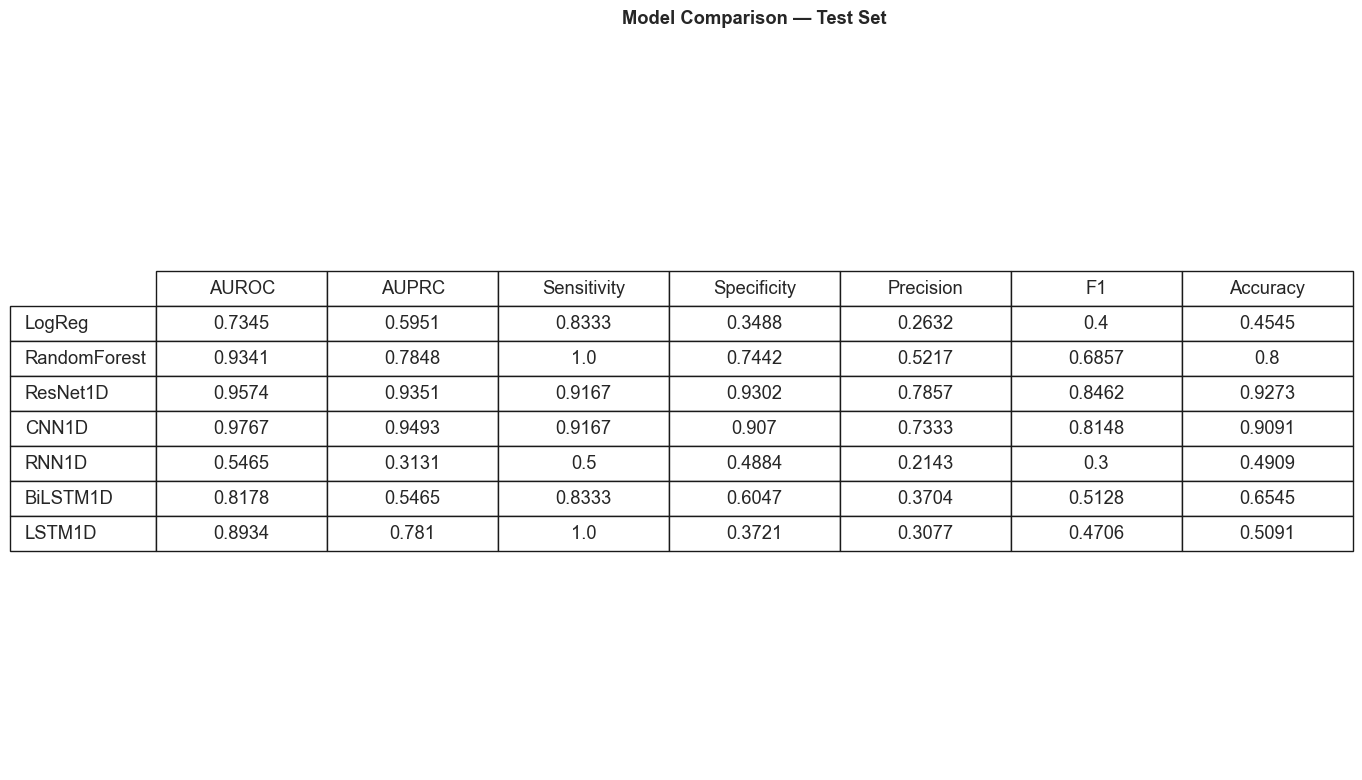


Model Comparison Table (Test Set):


,AUROC,AUPRC,Sensitivity,Specificity,Precision,F1,Accuracy
Model,,,,,,,
LogReg,0.7345,0.5951,0.8333,0.3488,0.2632,0.4000,0.4545
RandomForest,0.9341,0.7848,1.0000,0.7442,0.5217,0.6857,0.8000
ResNet1D,0.9574,0.9351,0.9167,0.9302,0.7857,0.8462,0.9273
CNN1D,0.9767,0.9493,0.9167,0.9070,0.7333,0.8148,0.9091
RNN1D,0.5465,0.3131,0.5000,0.4884,0.2143,0.3000,0.4909
BiLSTM1D,0.8178,0.5465,0.8333,0.6047,0.3704,0.5128,0.6545
LSTM1D,0.8934,0.7810,1.0000,0.3721,0.3077,0.4706,0.5091


In [8]:
df_cmp = compare_models(
    test_results,
    save_path=REPORTS / 'eval_model_comparison.png',
)
print('\nModel Comparison Table (Test Set):')
display(df_cmp)

## 5 — ROC and PR Curves

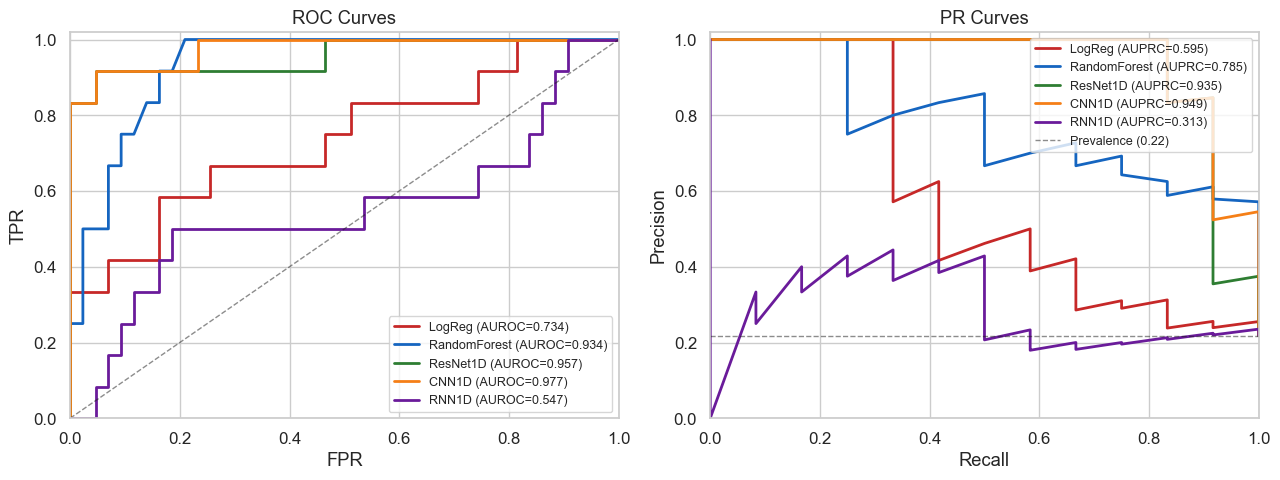

In [9]:
curve_data = {
    'LogReg':       {'y_true': y_test, 'y_prob': lr_prob_test},
    'RandomForest': {'y_true': y_test, 'y_prob': rf_prob_test},
    'ResNet1D':     {'y_true': y_test, 'y_prob': dl_prob_test},
    'CNN1D':  {'y_true': y_test, 'y_prob': dl_prob_test_2},
    'RNN1D':        {'y_true': y_test, 'y_prob': dl_prob_test_3},
    'BiLSTM1D':     {'y_true': y_test, 'y_prob': dl_prob_test_4},
    'LSTM1D':       {'y_true': y_test, 'y_prob': dl_prob_test_5},
}

plot_roc_pr_curves(curve_data, save_path=REPORTS / 'eval_roc_pr_curves.png')

## 6 — Confusion Matrices

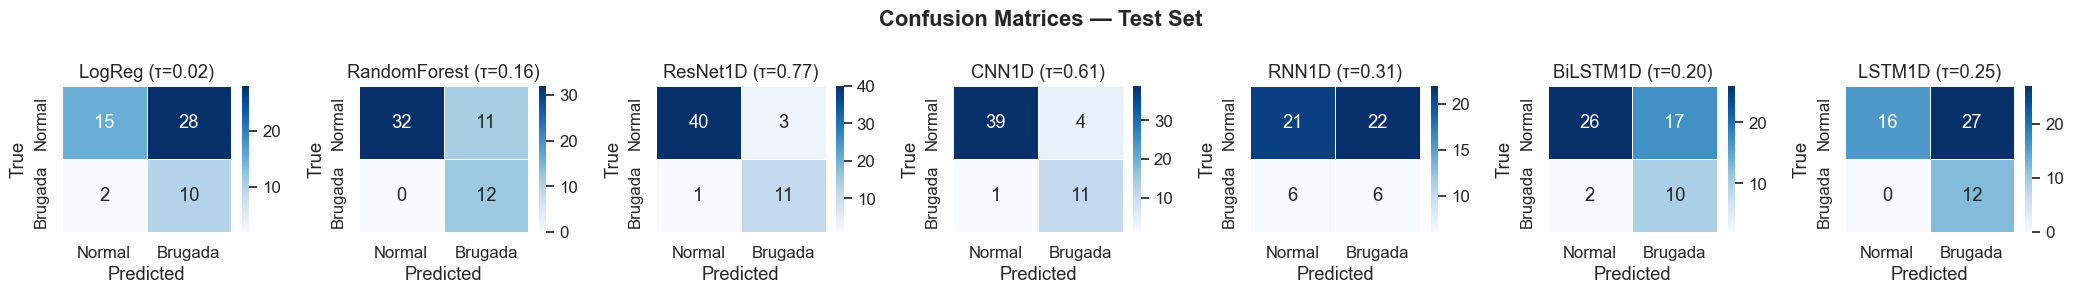

In [13]:
fig, axes = plt.subplots(1, 7, figsize=(21, 3))

for ax, probs, thresh, name in [
    (axes[0], lr_prob_test,  thresh_lr, f'LogReg (τ={thresh_lr:.2f})'),
    (axes[1], rf_prob_test,  thresh_rf, f'RandomForest (τ={thresh_rf:.2f})'),
    (axes[2], dl_prob_test,  thresh_dl, f'ResNet1D (τ={thresh_dl:.2f})'),
    (axes[3], dl_prob_test_2, thresh_dl_2, f'CNN1D (τ={thresh_dl_2:.2f})'),
    (axes[4], dl_prob_test_3, thresh_dl_3, f'RNN1D (τ={thresh_dl_3:.2f})'),
    (axes[5], dl_prob_test_4, thresh_dl_4, f'BiLSTM1D (τ={thresh_dl_4:.2f})'),
    (axes[6], dl_prob_test_5, thresh_dl_5, f'LSTM1D (τ={thresh_dl_5:.2f})'),
]:
    plot_confusion_matrix(
        y_test, (probs >= thresh).astype(int),
        ax=ax, title=name
    )

plt.suptitle('Confusion Matrices — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'eval_confusion_matrices.png', dpi=150)
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix

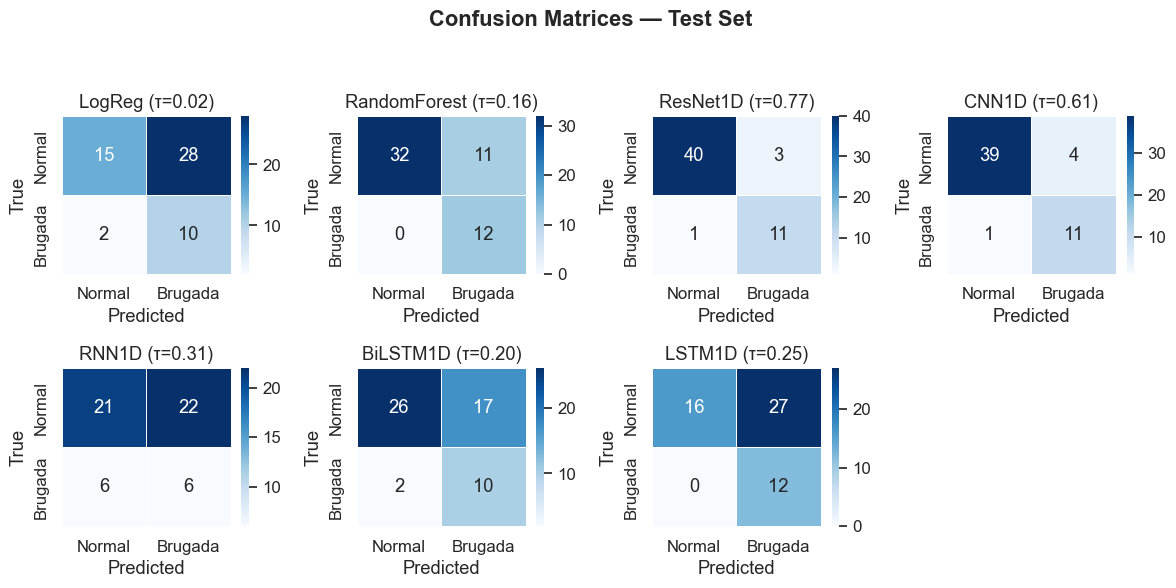

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

models = [
    (lr_prob_test,  thresh_lr,  f'LogReg (τ={thresh_lr:.2f})'),
    (rf_prob_test,  thresh_rf,  f'RandomForest (τ={thresh_rf:.2f})'),
    (dl_prob_test,  thresh_dl,  f'ResNet1D (τ={thresh_dl:.2f})'),
    (dl_prob_test_2, thresh_dl_2, f'CNN1D (τ={thresh_dl_2:.2f})'),
    (dl_prob_test_3, thresh_dl_3, f'RNN1D (τ={thresh_dl_3:.2f})'),
    (dl_prob_test_4, thresh_dl_4, f'BiLSTM1D (τ={thresh_dl_4:.2f})'),
    (dl_prob_test_5, thresh_dl_5, f'LSTM1D (τ={thresh_dl_5:.2f})'),
]

for ax, (probs, thresh, name) in zip(axes, models):
    plot_confusion_matrix(
        y_test, (probs >= thresh).astype(int),
        ax=ax, title=name
    )

# hide unused subplot
axes[-1].axis('off')

# ✅ ADD TITLE
plt.suptitle('Confusion Matrices — Test Set', fontweight='bold')

# ✅ FIX OVERLAP HERE
plt.tight_layout(rect=[0, 0, 1, 0.94])  # adjust 0.94 → 0.92 if still tight

# ✅ SAVE AFTER layout is fixed
plt.savefig(REPORTS / 'eval_confusion_matrices_2row.png', dpi=250, bbox_inches='tight')

plt.show()

## 7 — Calibration Curve

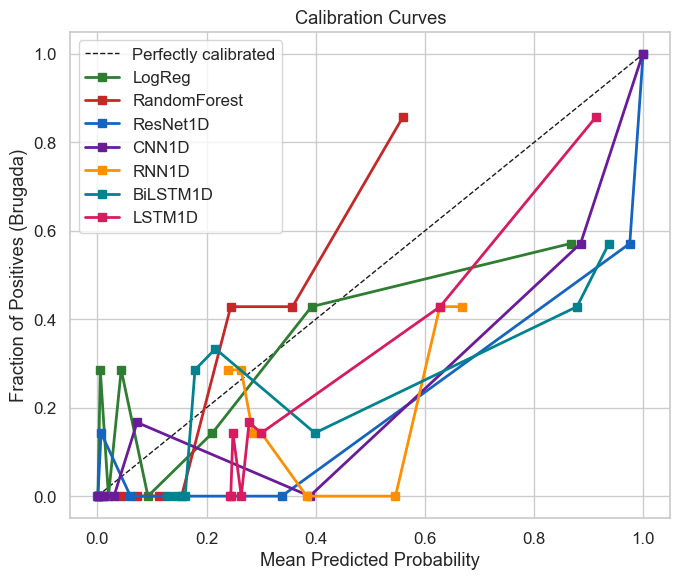

In [14]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfectly calibrated')

for name, prob, color in [
    ('LogReg',       lr_prob_test, '#2E7D32'),
    ('RandomForest', rf_prob_test, '#C62828'),
    ('ResNet1D',     dl_prob_test, '#1565C0'),
    ('CNN1D',  dl_prob_test_2, '#6A1B9A'),
    ('RNN1D',        dl_prob_test_3, '#FF8F00'),
    ('BiLSTM1D',     dl_prob_test_4, '#00838F'),
    ('LSTM1D',       dl_prob_test_5, '#D81B60'),
]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac_pos, 's-', color=color, lw=2, label=name)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Brugada)')
ax.set_title('Calibration Curves')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'eval_calibration.png', dpi=150)
plt.show()

## 8 — Error Analysis: False Negatives (Missed Brugada)

In [12]:
dl_pred_test = (dl_prob_test >= thresh_dl).astype(int)

# False Negatives = Brugada patients predicted as Normal
fn_mask = (y_test == 1) & (dl_pred_test == 0)
# False Positives = Normal patients predicted as Brugada
fp_mask = (y_test == 0) & (dl_pred_test == 1)

fn_ids = [ids_test[i] for i in np.where(fn_mask)[0]]
fp_ids = [ids_test[i] for i in np.where(fp_mask)[0]]

print(f'ResNet1D False Negatives (missed Brugada): {len(fn_ids)}')
print(f'  IDs: {fn_ids}')
print(f'\nResNet1D False Positives (normal flagged): {len(fp_ids)}')
print(f'  IDs: {fp_ids}')

ResNet1D False Negatives (missed Brugada): 1
  IDs: ['3043155']

ResNet1D False Positives (normal flagged): 3
  IDs: ['1236012', '325966', '1342979']


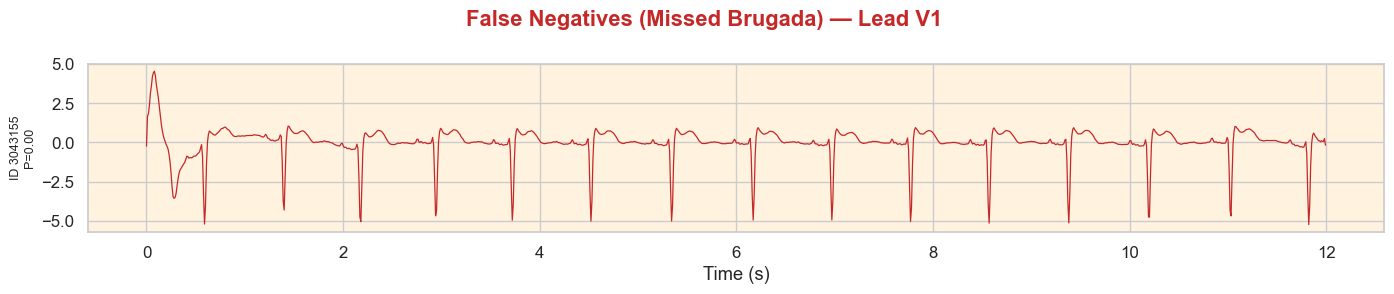

In [13]:
# Plot V1 for all FN patients to understand what the model missed
if len(fn_ids) > 0:
    n_fn = len(fn_ids)
    fig, axes = plt.subplots(n_fn, 1, figsize=(14, 3 * n_fn), sharex=True, squeeze=False)
    v1_idx = cfg.LEAD_NAMES.index('V1')
    time   = np.arange(cfg.N_SAMPLES) / cfg.FS

    for i, pid in enumerate(fn_ids):
        idx = ids_test.index(pid)
        sig = X_test[idx, v1_idx]
        prob = dl_prob_test[idx]
        axes[i][0].plot(time, sig, color='#C62828', lw=0.9)
        axes[i][0].set_ylabel(f'ID {pid}\nP={prob:.2f}', fontsize=9)
        axes[i][0].set_facecolor('#FFF3E0')

    axes[-1][0].set_xlabel('Time (s)')
    plt.suptitle('False Negatives (Missed Brugada) — Lead V1', fontweight='bold', color='#C62828')
    plt.tight_layout()
    plt.savefig(REPORTS / 'eval_false_negatives.png', dpi=150)
    plt.show()
else:
    print('No false negatives!')

## 9 — Score Distribution

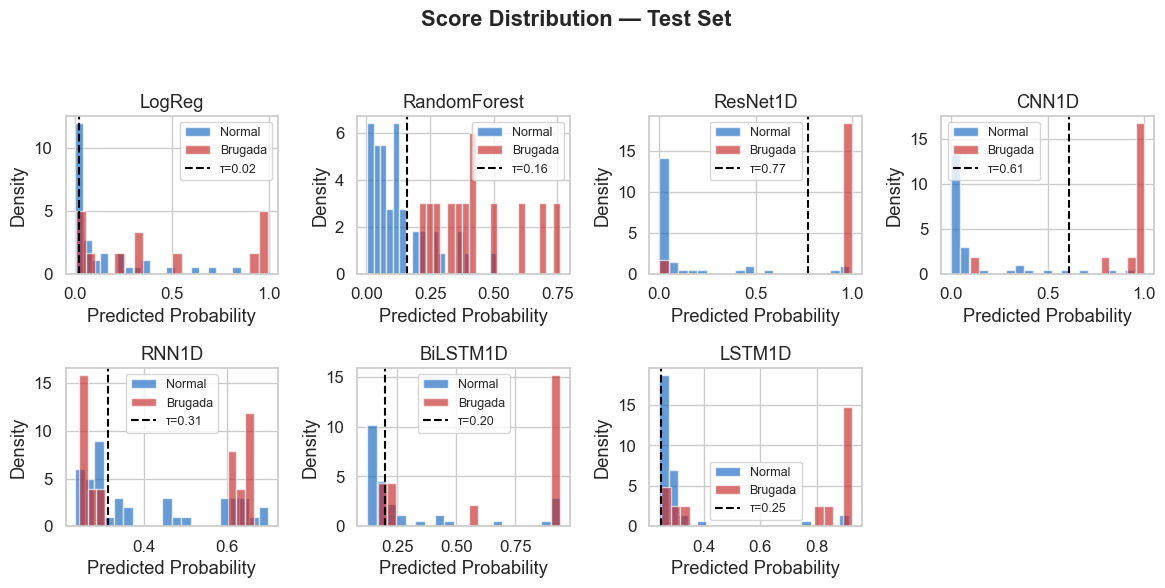

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for ax, probs, thresh, name in [
    (axes[0], lr_prob_test,  thresh_lr, 'LogReg'),
    (axes[1], rf_prob_test,  thresh_rf, 'RandomForest'),
    (axes[2], dl_prob_test,  thresh_dl, 'ResNet1D'),
    (axes[3], dl_prob_test_2, thresh_dl_2, 'CNN1D'),
    (axes[4], dl_prob_test_3, thresh_dl_3, 'RNN1D'),
    (axes[5], dl_prob_test_4, thresh_dl_4, 'BiLSTM1D'),
    (axes[6], dl_prob_test_5, thresh_dl_5, 'LSTM1D'),
]:
    ax.hist(probs[y_test == 0], bins=20, density=True, alpha=0.65,
            color='#1565C0', label='Normal')
    ax.hist(probs[y_test == 1], bins=20, density=True, alpha=0.65,
            color='#C62828', label='Brugada')
    ax.axvline(thresh, color='black', linestyle='--', lw=1.5, label=f'τ={thresh:.2f}')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title(name)
    ax.legend(fontsize=9)

# hide unused subplot
axes[-1].axis('off')

# ✅ ADD TITLE
plt.suptitle('Score Distribution — Test Set', fontweight='bold')

# ✅ FIX OVERLAP HERE
plt.tight_layout(rect=[0, 0, 1, 0.94])  # adjust 0.94 → 0.92 if still tight

# ✅ SAVE AFTER layout is fixed
plt.savefig(REPORTS / 'eval_score_distribution_2row.png', dpi=250, bbox_inches='tight')

## Summary

All figures saved to `reports/`. Proceed to `05_interpretability.ipynb`.

In [15]:
# Save test predictions for notebook 05
import pickle
test_preds = {
    'LogReg':       {'y_true': y_test, 'y_prob': lr_prob_test,
                     'threshold': thresh_lr, 'ids': ids_test},
    'RandomForest': {'y_true': y_test, 'y_prob': rf_prob_test,
                     'threshold': thresh_rf, 'ids': ids_test},
    'ResNet1D':     {'y_true': y_test, 'y_prob': dl_prob_test,
                     'threshold': thresh_dl, 'ids': ids_test},
}
with open(cfg.MODELS_DIR / 'test_predictions.pkl', 'wb') as f:
    pickle.dump(test_preds, f)

print('Test predictions saved. Proceed to 05_interpretability.ipynb.')

Test predictions saved. Proceed to 05_interpretability.ipynb.
